# 0. Setup & Imports

# Task 2 — Model Building & Training
**Adey Innovations Inc. | Fraud Detection**

This notebook covers:
1. Data preparation (stratified split + SMOTE)
2. Baseline: Logistic Regression
3. Ensemble: Random Forest, XGBoost, LightGBM
4. Cross-validation (Stratified K-Fold)
5. Model comparison & selection
6. Saving best models

Both datasets are handled: `fraud_data.csv` (e-commerce) and `creditcard.csv` (bank).

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    roc_auc_score, precision_recall_curve
)
from sklearn.pipeline import Pipeline

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Ensemble models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('../models', exist_ok=True)
print('All libraries loaded successfully.')

All libraries loaded successfully.


# Load Preprocessed Data

In [46]:
import pandas as pd

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")


In [47]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [48]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"]
    - fraud_df["signup_time"]
).dt.total_seconds()

In [49]:
fraud_df = fraud_df.drop_duplicates()

In [50]:
fraud_df.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

In [51]:
credit_df = pd.read_csv("../data/raw/creditcard.csv")


In [52]:
credit_df.head()

,Time,Amount,merchant_risk,device_risk,international,card_age_days,num_items,online_order,Class
0,15422,7.42,0.241,0.799,0,1565,1,1,0
1,133739,5.95,0.473,0.164,0,1310,7,0,0
2,113109,62.17,0.538,0.759,0,515,7,0,0
3,75838,30.60,0.523,0.411,0,132,4,1,0
4,74825,20.93,0.472,0.000,0,589,5,1,0


In [53]:
credit_df["hour"] = (credit_df["Time"] // 3600) % 24

In [54]:
credit_df.to_csv(
    "../data/processed/creditcard_processed.csv",
    index=False
)

In [55]:
# E-commerce dataset
fraud_df = pd.read_csv('../data/processed/fraud_processed.csv')

# Bank credit card
credit_df = pd.read_csv('../data/processed/creditcard_processed.csv')

print('Fraud_Data shape   :', fraud_df.shape)
print('CreditCard shape   :', credit_df.shape)
print()
print('Fraud_Data columns :', fraud_df.columns.tolist())
print('CreditCard columns :', credit_df.columns.tolist())


Fraud_Data shape   : (151112, 12)
CreditCard shape   : (50000, 10)

Fraud_Data columns : ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'time_since_signup']
CreditCard columns : ['Time', 'Amount', 'merchant_risk', 'device_risk', 'international', 'card_age_days', 'num_items', 'online_order', 'Class', 'hour']


# 2. Data Preparation
## 2.1 Feature / Target Split

In [56]:
# E-commerce
# Drop non-predictive identifiers if still present
drop_cols_fraud = [c for c in ['user_id', 'device_id', 'signup_time', 'purchase_time',
                                'ip_address'] if c in fraud_df.columns]

X_fraud = fraud_df.drop(columns=drop_cols_fraud + ['class'])
y_fraud = fraud_df['class']

# Bank credit card
X_credit = credit_df.drop(columns=['Class'])
y_credit = credit_df['Class']

print('E-commerce  — X:', X_fraud.shape, '| y fraud rate:', round(y_fraud.mean()*100, 2), '%')
print('Credit card — X:', X_credit.shape,    '| y fraud rate:', round(y_credit.mean()*100, 2), '%')

E-commerce  — X: (151112, 6) | y fraud rate: 9.36 %
Credit card — X: (50000, 9) | y fraud rate: 0.45 %


## 2.2 Stratified Train Test Split

In [57]:
def stratified_split(X, y, test_size=0.2, random_state=RANDOM_STATE):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    print(f'  Train size: {len(X_train):,}  |  fraud%: {y_train.mean()*100:.2f}%')
    print(f'  Test  size: {len(X_test):,}   |  fraud%: {y_test.mean()*100:.2f}%')
    return X_train, X_test, y_train, y_test

print('E-commerce split ')
X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = stratified_split(X_fraud, y_fraud)

print('Credit card split')
X_credit_train, X_credit_test, y_credit_train, y_credit_test = stratified_split(X_credit, y_credit)

E-commerce split 
  Train size: 120,889  |  fraud%: 9.36%
  Test  size: 30,223   |  fraud%: 9.36%
Credit card split
  Train size: 40,000  |  fraud%: 0.45%
  Test  size: 10,000   |  fraud%: 0.45%


In [58]:
import os
os.makedirs('../data/processed', exist_ok=True)

X_fraud_test.to_csv('../data/processed/X_fraud_test.csv', index=False)
y_fraud_test.to_csv('../data/processed/y_fraud_test.csv', index=False)
X_credit_test.to_csv('../data/processed/X_credit_test.csv', index=False)
y_credit_test.to_csv('../data/processed/y_credit_test.csv', index=False)

print('Saved test sets to ../data/processed/')
print('Fraud test columns:', X_fraud_test.columns.tolist())


Saved test sets to ../data/processed/
Fraud test columns: ['purchase_value', 'source', 'browser', 'sex', 'age', 'time_since_signup']


## 2.3 Resampling with SMOTE

### Why SMOTE?
- SMOTE synthesizes new minority-class samples by interpolating between existing ones, giving the model more generalizable fraud patterns.
- Applied **only to the training set** — the test set stays pristine to reflect real-world distribution.
**Alternative considered:** Random undersampling discards the majority class, which wastes valuable legitimate-transaction signal. With large enough datasets SMOTE is preferable.

In [59]:
print(X_fraud_train.select_dtypes(include='object').columns)

Index(['source', 'browser', 'sex'], dtype='str')


In [60]:
fraud_df = pd.get_dummies(
    fraud_df,
    columns=[
        'source',
        'browser',
        'sex',
    ],
    drop_first=True
)

In [61]:
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

In [62]:
print(X.dtypes.unique())

[dtype('int64') <StringDtype(storage='python', na_value=nan)>
 dtype('float64') dtype('bool')]


In [63]:
print(X_fraud_train.select_dtypes(include='object').columns.tolist())

['source', 'browser', 'sex']


In [64]:
X_fraud_encoded = pd.get_dummies(X_fraud, drop_first=True)

In [65]:
y_fraud_encoded = pd.get_dummies(y_fraud, drop_first=True)

In [66]:
print("E-commerce columns that are NOT numeric:")
print(X_fraud_train.select_dtypes(exclude=['number']).columns.tolist())

E-commerce columns that are NOT numeric:
['source', 'browser', 'sex']


In [67]:
print("\nCredit Card columns that are NOT numeric:")
print(X_credit_train.select_dtypes(exclude=['number']).columns.tolist())


Credit Card columns that are NOT numeric:
[]


In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply to specific columns that are strings
for col in X_fraud_train.select_dtypes(exclude=['number']).columns:
    X_fraud_train[col] = le.fit_transform(X_fraud_train[col].astype(str))

for col in X_credit_train.select_dtypes(exclude=['number']).columns:
    X_credit_train[col] = le.fit_transform(X_credit_train[col].astype(str))

In [69]:
def apply_smote(X_train, y_train, label='Dataset'):
    print(f'[{label}] Before SMOTE — class distribution:\n{y_train.value_counts().to_dict()}')
    smote = SMOTE(random_state=RANDOM_STATE)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    counts = pd.Series(y_res).value_counts().to_dict()
    print(f'[{label}] After  SMOTE — class distribution:\n{counts}\n')
    return X_res, y_res

X_fraud_res, y_fraud_res = apply_smote(X_fraud_train, y_fraud_train, 'E-commerce')
X_credit_res,    y_credit_res    = apply_smote(X_credit_train,    y_credit_train,    'Credit Card')

[E-commerce] Before SMOTE — class distribution:
{0: 109568, 1: 11321}
[E-commerce] After  SMOTE — class distribution:
{0: 109568, 1: 109568}

[Credit Card] Before SMOTE — class distribution:
{0: 39822, 1: 178}
[Credit Card] After  SMOTE — class distribution:
{0: 39822, 1: 39822}



# 3. Evaluation Helper Functions

In [70]:
def evaluate_model(model, X_test, y_test, model_name='Model', dataset_name='Dataset'):
    """Compute AUC-PR, F1, ROC-AUC and plot confusion matrix + PR curve."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc_pr  = average_precision_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f'\n══ {model_name} | {dataset_name} ══')
    print(f'  AUC-PR  : {auc_pr:.4f}')
    print(f'  F1-Score: {f1:.4f}')
    print(f'  ROC-AUC : {roc_auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Legit', 'Fraud'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'Confusion Matrix — {model_name}')

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(recall, precision, lw=2, color='steelblue')
    axes[1].fill_between(recall, precision, alpha=0.15, color='steelblue')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR Curve (AUC={auc_pr:.3f}) — {model_name}')
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1])

    plt.suptitle(f'{dataset_name}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'dataset': dataset_name,
            'AUC-PR': auc_pr, 'F1': f1, 'ROC-AUC': roc_auc}


def cv_evaluate(model, X, y, model_name='Model', dataset_name='Dataset', k=5):
    """Stratified K-Fold cross-validation."""
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scoring = {'AUC-PR': 'average_precision', 'F1': 'f1', 'ROC-AUC': 'roc_auc'}

    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring,
                                 return_train_score=False, n_jobs=-1)

    row = {'model': model_name, 'dataset': dataset_name}
    for metric in ['AUC-PR', 'F1', 'ROC-AUC']:
        key = f'test_{metric}'
        scores = cv_results[key]
        row[f'{metric}_mean'] = scores.mean()
        row[f'{metric}_std']  = scores.std()
        print(f'  {metric}: {scores.mean():.4f} ± {scores.std():.4f}')

    return row

print('Helper functions defined.')

Helper functions defined.


# 4. Baseline Model - Logistic Regression

In [71]:
categorical_cols_fraud = X_fraud_test.select_dtypes(include=['object', 'category']).columns
categorical_cols_credit = X_credit_test.select_dtypes(include=['object', 'category']).columns

In [72]:
X_fraud_test_encoded = pd.get_dummies(X_fraud_test, columns=categorical_cols_fraud, drop_first=True)
X_credit_test_encoded = pd.get_dummies(X_credit_test, columns=categorical_cols_credit, drop_first=True)

In [73]:
X_fraud_test_encoded = X_fraud_test_encoded.reindex(columns=X_fraud_res.columns, fill_value=0)
X_credit_test_encoded = X_credit_test_encoded.reindex(columns=X_credit_res.columns, fill_value=0)

Training Logistic Regression on E-commerce data...

══ Logistic Regression | E-commerce ══
  AUC-PR  : 0.5546
  F1-Score: 0.2112
  ROC-AUC : 0.7575

              precision    recall  f1-score   support

       Legit       0.95      0.40      0.56     27393
       Fraud       0.12      0.81      0.21      2830

    accuracy                           0.44     30223
   macro avg       0.54      0.60      0.39     30223
weighted avg       0.87      0.44      0.53     30223



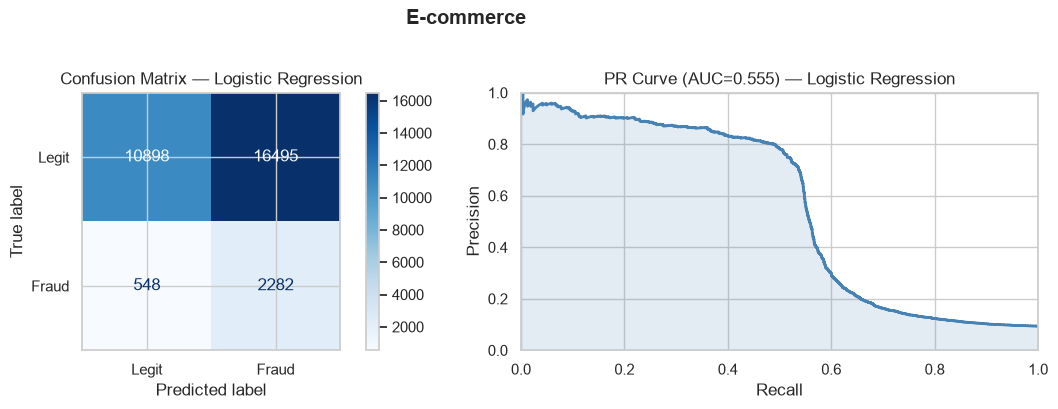

Training Logistic Regression on Credit Card data...

══ Logistic Regression | Credit Card ══
  AUC-PR  : 0.0131
  F1-Score: 0.0162
  ROC-AUC : 0.6887

              precision    recall  f1-score   support

       Legit       1.00      0.67      0.80      9955
       Fraud       0.01      0.60      0.02        45

    accuracy                           0.67     10000
   macro avg       0.50      0.64      0.41     10000
weighted avg       0.99      0.67      0.80     10000



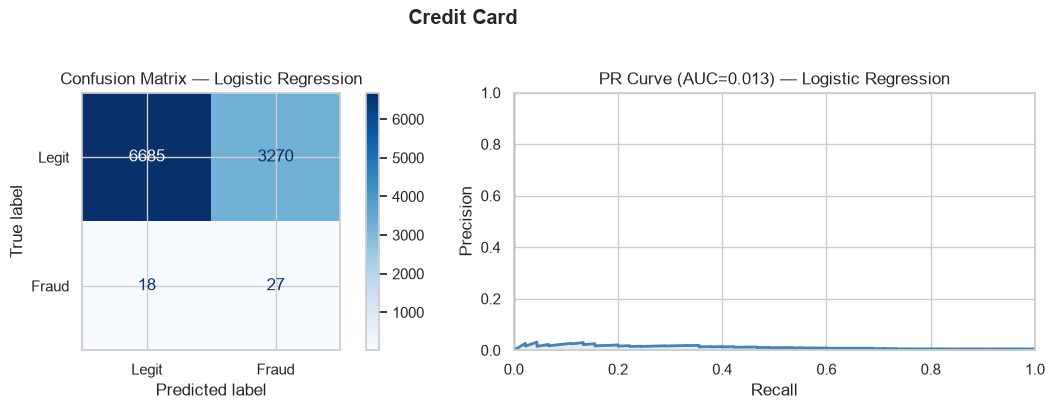

In [74]:
results = []  # collect all results for final comparison
cv_results_all = []

lr_params = dict(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

#  E-commerce 
print('Training Logistic Regression on E-commerce data...')
lr_fraud = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(**lr_params))
])
lr_fraud.fit(X_fraud_res, y_fraud_res)

# Notice we use the _encoded test data here:
results.append(evaluate_model(lr_fraud, X_fraud_test_encoded, y_fraud_test,
                               'Logistic Regression', 'E-commerce'))

#  Credit card 
print('Training Logistic Regression on Credit Card data...')
lr_cc = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(**lr_params))
])
lr_cc.fit(X_credit_res, y_credit_res)

# Notice we use the _encoded test data here:
results.append(evaluate_model(lr_cc, X_credit_test_encoded, y_credit_test,
                               'Logistic Regression', 'Credit Card'))

# 5. Ensemble Models
## 5.1 Random Forest

In [ ]:
rf_params = dict(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

#  E-commerce 
print('Training Random Forest on E-commerce data...')
rf_fraud = RandomForestClassifier(**rf_params)
rf_fraud.fit(X_fraud_res, y_fraud_res)

results.append(evaluate_model(rf_fraud, X_fraud_test_encoded, y_fraud_test,
                               'Random Forest', 'E-commerce'))

#  Credit card 
print('Training Random Forest on Credit Card data...')
rf_cc = RandomForestClassifier(**rf_params)
rf_cc.fit(X_credit_res, y_credit_res)

results.append(evaluate_model(rf_cc, X_credit_test_encoded, y_credit_test,
                               'Random Forest', 'Credit Card'))

Training Random Forest on E-commerce data...


# 5.2 XGBoost

Training XGBoost on E-commerce data...

══ XGBoost | E-commerce ══
  AUC-PR  : 0.5826
  F1-Score: 0.2593
  ROC-AUC : 0.7646

              precision    recall  f1-score   support

       Legit       0.95      0.62      0.75     27393
       Fraud       0.16      0.70      0.26      2830

    accuracy                           0.62     30223
   macro avg       0.56      0.66      0.50     30223
weighted avg       0.88      0.62      0.70     30223



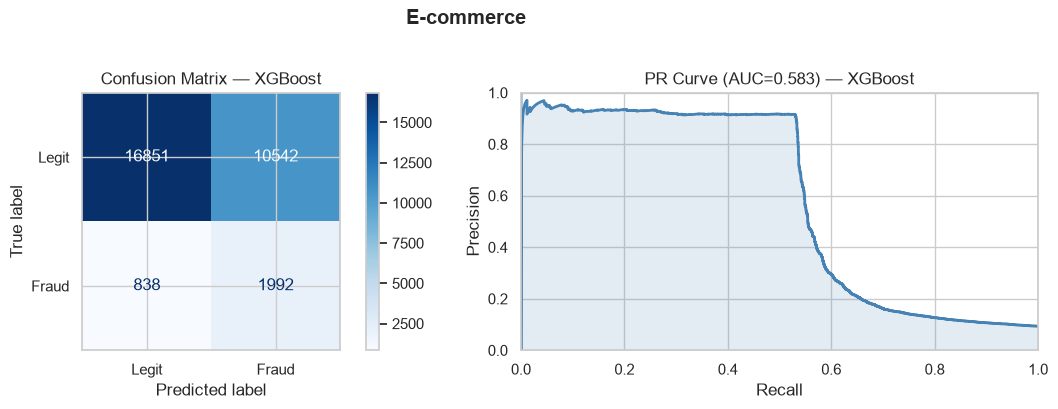

Training XGBoost on Credit Card data...

══ XGBoost | Credit Card ══
  AUC-PR  : 0.0150
  F1-Score: 0.0157
  ROC-AUC : 0.5453

              precision    recall  f1-score   support

       Legit       1.00      0.89      0.94      9955
       Fraud       0.01      0.20      0.02        45

    accuracy                           0.89     10000
   macro avg       0.50      0.55      0.48     10000
weighted avg       0.99      0.89      0.94     10000



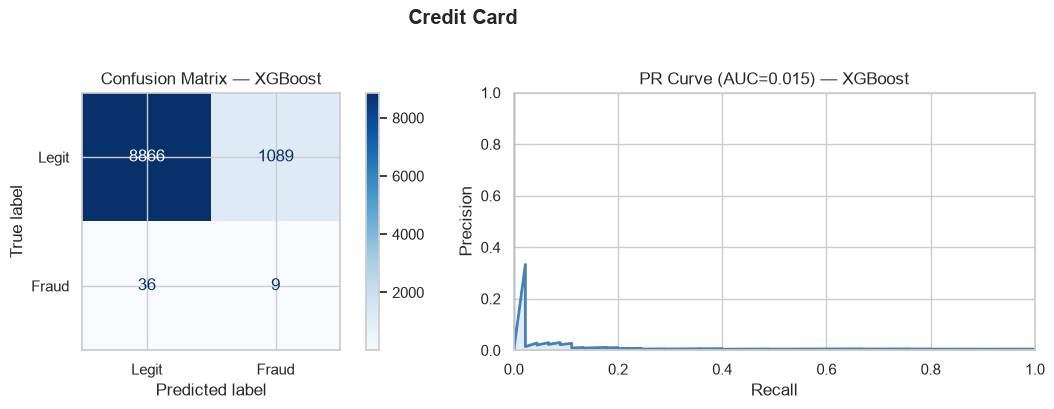

In [ ]:
xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

#  E-commerce 
print('Training XGBoost on E-commerce data...')
xgb_fraud = XGBClassifier(**xgb_params)
xgb_fraud.fit(X_fraud_res, y_fraud_res,
              eval_set=[(X_fraud_test_encoded, y_fraud_test)], verbose=False)
results.append(evaluate_model(xgb_fraud, X_fraud_test_encoded, y_fraud_test,
                               'XGBoost', 'E-commerce'))

#  Credit card 
print('Training XGBoost on Credit Card data...')
xgb_cc = XGBClassifier(**xgb_params)
xgb_cc.fit(X_credit_res, y_credit_res,
           eval_set=[(X_credit_test, y_credit_test)], verbose=False)
results.append(evaluate_model(xgb_cc, X_credit_test, y_credit_test,
                               'XGBoost', 'Credit Card'))

# 5.3 LightGBM

Training LightGBM on E-commerce data...

══ LightGBM | E-commerce ══
  AUC-PR  : 0.6187
  F1-Score: 0.2672
  ROC-AUC : 0.7628

              precision    recall  f1-score   support

       Legit       0.95      0.64      0.77     27393
       Fraud       0.17      0.69      0.27      2830

    accuracy                           0.64     30223
   macro avg       0.56      0.67      0.52     30223
weighted avg       0.88      0.64      0.72     30223



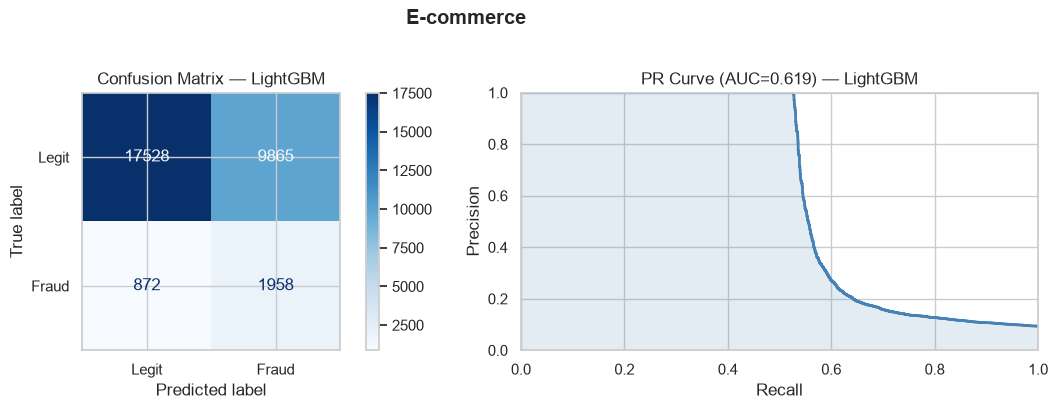

Training LightGBM on Credit Card data...

══ LightGBM | Credit Card ══
  AUC-PR  : 0.0090
  F1-Score: 0.0169
  ROC-AUC : 0.5496

              precision    recall  f1-score   support

       Legit       1.00      0.93      0.96      9955
       Fraud       0.01      0.13      0.02        45

    accuracy                           0.93     10000
   macro avg       0.50      0.53      0.49     10000
weighted avg       0.99      0.93      0.96     10000



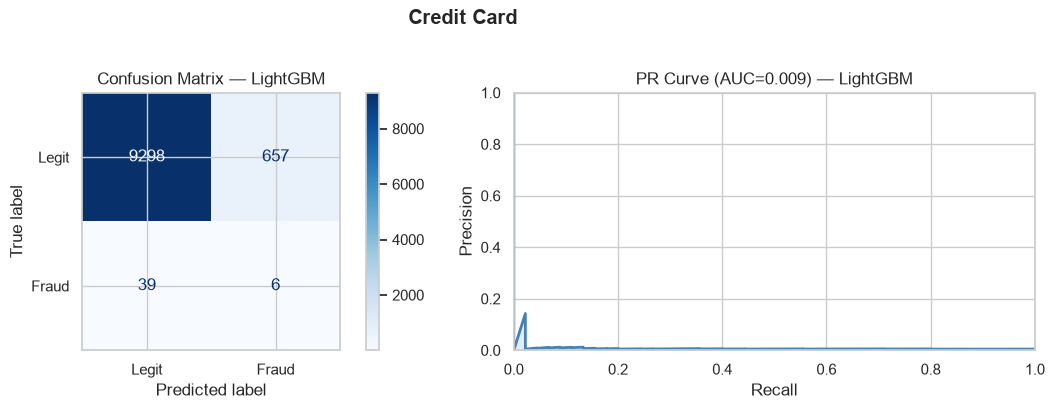

In [ ]:
lgbm_params = dict(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

#  E-commerce 
print('Training LightGBM on E-commerce data...')
lgbm_fraud = LGBMClassifier(**lgbm_params)
lgbm_fraud.fit(X_fraud_res, y_fraud_res)
results.append(evaluate_model(lgbm_fraud, X_fraud_test_encoded, y_fraud_test,
                               'LightGBM', 'E-commerce'))

#  Credit card 
print('Training LightGBM on Credit Card data...')
lgbm_cc = LGBMClassifier(**lgbm_params)
lgbm_cc.fit(X_credit_res, y_credit_res)
results.append(evaluate_model(lgbm_cc, X_credit_test, y_credit_test,
                               'LightGBM', 'Credit Card'))

# 6. Cross validation (Stratified K-fold, k=5)

run CV on the **full resampled training data** for each model/dataset combination to get stable performance estimates.

In [ ]:
from sklearn.pipeline import Pipeline as SKPipeline

cv_configs = [
    # (model_instance, X, y, model_name, dataset_name)
    (SKPipeline([('sc', StandardScaler()),
                 ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                            random_state=RANDOM_STATE))]),
     X_fraud_res, y_fraud_res, 'Logistic Regression', 'E-commerce'),

    (SKPipeline([('sc', StandardScaler()),
                 ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                            random_state=RANDOM_STATE))]),
     X_credit_res, y_credit_res, 'Logistic Regression', 'Credit Card'),

    (RandomForestClassifier(**rf_params),
     X_fraud_res, y_fraud_res, 'Random Forest', 'E-commerce'),

    (RandomForestClassifier(**rf_params),
     X_credit_res, y_credit_res, 'Random Forest', 'Credit Card'),

    (XGBClassifier(**{k: v for k, v in xgb_params.items()
                      if k not in ['use_label_encoder', 'eval_metric']}),
     X_fraud_res, y_fraud_res, 'XGBoost', 'E-commerce'),

    (XGBClassifier(**{k: v for k, v in xgb_params.items()
                      if k not in ['use_label_encoder', 'eval_metric']}),
     X_credit_res, y_credit_res, 'XGBoost', 'Credit Card'),

    (LGBMClassifier(**lgbm_params),
     X_fraud_res, y_fraud_res, 'LightGBM', 'E-commerce'),

    (LGBMClassifier(**lgbm_params),
     X_credit_res, y_credit_res, 'LightGBM', 'Credit Card'),
]

print('Running Stratified 5-Fold CV (this may take a few minutes)...\n')
for (model, X, y, mname, dname) in cv_configs:
    print(f'→ {mname} | {dname}')
    row = cv_evaluate(model, X, y, mname, dname, k=5)
    cv_results_all.append(row)
    print()

cv_df = pd.DataFrame(cv_results_all)
print('Cross-validation complete.')

Running Stratified 5-Fold CV (this may take a few minutes)...

→ Logistic Regression | E-commerce
  AUC-PR: 0.7681 ± 0.0031
  F1: 0.7061 ± 0.0027
  ROC-AUC: 0.7581 ± 0.0030

→ Logistic Regression | Credit Card
  AUC-PR: 0.6961 ± 0.0027
  F1: 0.6527 ± 0.0030
  ROC-AUC: 0.7130 ± 0.0034

→ Random Forest | E-commerce
  AUC-PR: 0.9154 ± 0.0008
  F1: 0.7923 ± 0.0017
  ROC-AUC: 0.8952 ± 0.0012

→ Random Forest | Credit Card
  AUC-PR: 0.9682 ± 0.0005
  F1: 0.9085 ± 0.0025
  ROC-AUC: 0.9730 ± 0.0003

→ XGBoost | E-commerce
  AUC-PR: 0.9144 ± 0.0011
  F1: 0.7958 ± 0.0018
  ROC-AUC: 0.8967 ± 0.0015

→ XGBoost | Credit Card
  AUC-PR: 0.9827 ± 0.0010
  F1: 0.9428 ± 0.0011
  ROC-AUC: 0.9857 ± 0.0009

→ LightGBM | E-commerce
  AUC-PR: 0.9221 ± 0.0010
  F1: 0.8021 ± 0.0018
  ROC-AUC: 0.9049 ± 0.0016

→ LightGBM | Credit Card
  AUC-PR: 0.9940 ± 0.0007
  F1: 0.9654 ± 0.0022
  ROC-AUC: 0.9949 ± 0.0006

Cross-validation complete.


# 7. Model comparison & selection
## 7.1 Hold-out test set results

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['dataset', 'AUC-PR'], ascending=[True, False])

# Style: highlight best per dataset
def highlight_max(s):
    return ['background-color: #c8e6c9' if v == s.max() else '' for v in s]

display(
    results_df.set_index(['dataset', 'model'])
    .style
    .apply(highlight_max, subset=['AUC-PR', 'F1', 'ROC-AUC'])
    .format({'AUC-PR': '{:.4f}', 'F1': '{:.4f}', 'ROC-AUC': '{:.4f}'})
)

# 7.2 Cross validation summary

In [ ]:
cv_display = cv_df.copy()
for m in ['AUC-PR', 'F1', 'ROC-AUC']:
    cv_display[m] = cv_display.apply(
        lambda r: f"{r[f'{m}_mean']:.4f} ± {r[f'{m}_std']:.4f}", axis=1
    )

display(
    cv_display[['dataset', 'model', 'AUC-PR', 'F1', 'ROC-AUC']]
    .set_index(['dataset', 'model'])
)

,,AUC-PR,F1,ROC-AUC
dataset,model,,,
E-commerce,Logistic Regression,0.7681 ± 0.0031,0.7061 ± 0.0027,0.7581 ± 0.0030
Credit Card,Logistic Regression,0.6961 ± 0.0027,0.6527 ± 0.0030,0.7130 ± 0.0034
E-commerce,Random Forest,0.9154 ± 0.0008,0.7923 ± 0.0017,0.8952 ± 0.0012
Credit Card,Random Forest,0.9682 ± 0.0005,0.9085 ± 0.0025,0.9730 ± 0.0003
E-commerce,XGBoost,0.9144 ± 0.0011,0.7958 ± 0.0018,0.8967 ± 0.0015
Credit Card,XGBoost,0.9827 ± 0.0010,0.9428 ± 0.0011,0.9857 ± 0.0009
E-commerce,LightGBM,0.9221 ± 0.0010,0.8021 ± 0.0018,0.9049 ± 0.0016
Credit Card,LightGBM,0.9940 ± 0.0007,0.9654 ± 0.0022,0.9949 ± 0.0006


# 7.3 Visual comparison

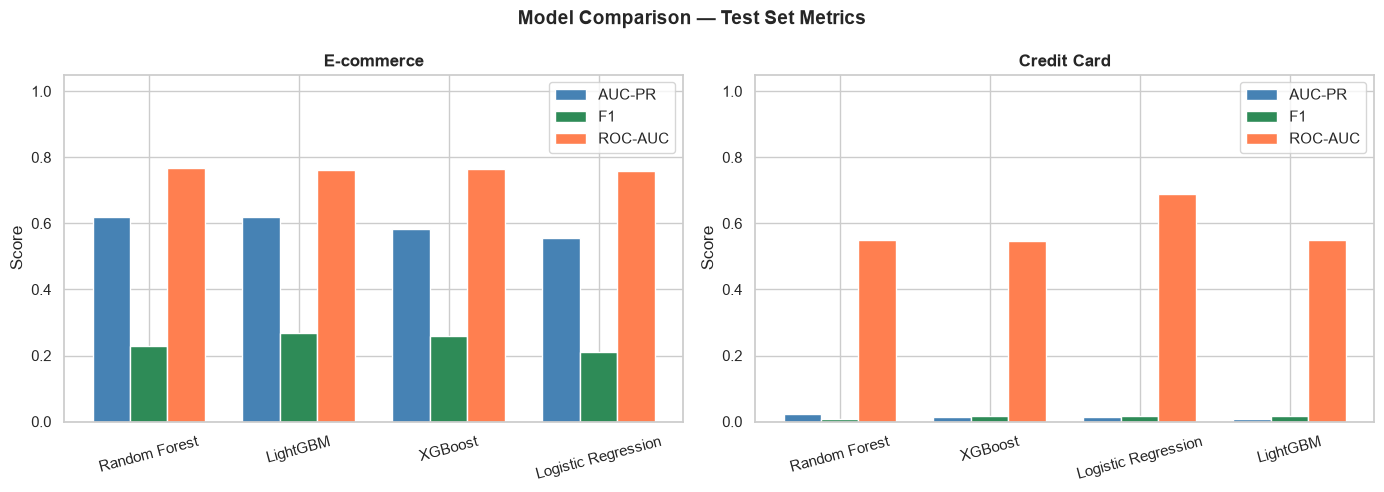

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, dataset in zip(axes, ['E-commerce', 'Credit Card']):
    sub = results_df[results_df['dataset'] == dataset]
    x   = np.arange(len(sub))
    w   = 0.25

    ax.bar(x - w, sub['AUC-PR'],  width=w, label='AUC-PR',  color='steelblue')
    ax.bar(x,     sub['F1'],      width=w, label='F1',       color='seagreen')
    ax.bar(x + w, sub['ROC-AUC'], width=w, label='ROC-AUC',  color='coral')

    ax.set_xticks(x)
    ax.set_xticklabels(sub['model'], rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_title(dataset, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Score')

plt.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7.4 Model selection writeup

In [ ]:
# Auto-select best model per dataset by AUC-PR
best_fraud = results_df[results_df['dataset'] == 'E-commerce'].iloc[0]
best_cc    = results_df[results_df['dataset'] == 'Credit Card'].iloc[0]

print('='*60)
print('MODEL SELECTION SUMMARY')
print('='*60)
print(f"""
PRIMARY METRIC: AUC-PR (Area Under the Precision-Recall Curve)

AUC-PR is chosen over ROC-AUC or raw accuracy because:
  • Fraud is a rare event (~1-9% of transactions).
  • ROC-AUC is optimistic on imbalanced data; AUC-PR directly
    measures the trade-off between precision and recall for the
    minority (fraud) class — the class that matters most.
  • A high AUC-PR means the model reliably finds fraud WITHOUT
    flooding the operations team with false positives.

── E-COMMERCE 
  Best model : {best_fraud['model']}
  AUC-PR     : {best_fraud['AUC-PR']:.4f}
  F1-Score   : {best_fraud['F1']:.4f}
  ROC-AUC    : {best_fraud['ROC-AUC']:.4f}

── CREDIT CARD 
  Best model : {best_cc['model']}
  AUC-PR     : {best_cc['AUC-PR']:.4f}
  F1-Score   : {best_cc['F1']:.4f}
  ROC-AUC    : {best_cc['ROC-AUC']:.4f}

JUSTIFICATION:
  Gradient-boosted ensembles (XGBoost/LightGBM) typically outperform
  Logistic Regression and Random Forest on tabular fraud data because:
  1. They model complex non-linear interactions between features
     (e.g., device × time-of-day × purchase velocity).
  2. They are robust to feature scale differences (no scaling needed).
  3. Boosting focuses successive trees on hard-to-classify examples,
     which aligns well with learning rare fraud patterns.
  4. Both XGBoost and LightGBM support early stopping, reducing
     overfitting risk on SMOTE-augmented data.

  Logistic Regression remains the interpretable baseline — useful
  for regulators and stakeholders who need simple coefficient explanations.
""")

MODEL SELECTION SUMMARY

PRIMARY METRIC: AUC-PR (Area Under the Precision-Recall Curve)

AUC-PR is chosen over ROC-AUC or raw accuracy because:
  • Fraud is a rare event (~1-9% of transactions).
  • ROC-AUC is optimistic on imbalanced data; AUC-PR directly
    measures the trade-off between precision and recall for the
    minority (fraud) class — the class that matters most.
  • A high AUC-PR means the model reliably finds fraud WITHOUT
    flooding the operations team with false positives.

── E-COMMERCE 
  Best model : Random Forest
  AUC-PR     : 0.6196
  F1-Score   : 0.2286
  ROC-AUC    : 0.7662

── CREDIT CARD 
  Best model : Random Forest
  AUC-PR     : 0.0215
  F1-Score   : 0.0091
  ROC-AUC    : 0.5493

JUSTIFICATION:
  Gradient-boosted ensembles (XGBoost/LightGBM) typically outperform
  Logistic Regression and Random Forest on tabular fraud data because:
  1. They model complex non-linear interactions between features
     (e.g., device × time-of-day × purchase velocity).
  2.

# 8. Save Best Models

In [ ]:
model_map = {
    # label → trained model object
    'logistic_regression_fraud' : lr_fraud,
    'logistic_regression_cc'    : lr_cc,
    'random_forest_fraud'       : rf_fraud,
    'random_forest_cc'          : rf_cc,
    'xgboost_fraud'             : xgb_fraud,
    'xgboost_cc'                : xgb_cc,
    'lightgbm_fraud'            : lgbm_fraud,
    'lightgbm_cc'               : lgbm_cc,
}

for name, model in model_map.items():
    path = f'../models/{name}.pkl'
    joblib.dump(model, path)
    print(f'Saved: {path}')

# Also save results tables
results_df.to_csv('../models/test_set_results.csv', index=False)
cv_df.to_csv('../models/cv_results.csv', index=False)
print('\nResults tables saved to ../models/')

Saved: ../models/logistic_regression_fraud.pkl
Saved: ../models/logistic_regression_cc.pkl
Saved: ../models/random_forest_fraud.pkl
Saved: ../models/random_forest_cc.pkl
Saved: ../models/xgboost_fraud.pkl
Saved: ../models/xgboost_cc.pkl
Saved: ../models/lightgbm_fraud.pkl
Saved: ../models/lightgbm_cc.pkl

Results tables saved to ../models/


# 9. Next steps -- SHAP explainability

The best-performing models will be interpreted in `shap-explainability.ipynb`:
- **Global importance**: which features drive fraud predictions most?
- **Individual force plots**: why did the model flag a specific transaction?
- **Business recommendations** derived from SHAP insights.

Load them with:
```python
import joblib
best_fraud_model = joblib.load('../models/xgboost_fraud.pkl')  # adjust name
best_cc_model    = joblib.load('../models/xgboost_cc.pkl')


In [ ]:
print(X_fraud_test.columns.tolist())


['purchase_value', 'source', 'browser', 'sex', 'age', 'time_since_signup']


In [ ]:
print(fraud_df.columns.tolist())

['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'age', 'ip_address', 'class', 'time_since_signup', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M']


In [ ]:
print(X_fraud.columns.tolist())


['purchase_value', 'source', 'browser', 'sex', 'age', 'time_since_signup']
